# 07 — Publication-Quality Visualizations

Institutional-research styling from `src/charts.py`: muted navy/gold palette, no chartjunk, `$B` axis formatting, source footnote. Every chart is also saved to `reports/figures/` for the README / a report.

In [1]:
# --- setup (run this cell first, every session) ---
import os, sys, pathlib

# Option A: Google Drive (data persists across sessions -- recommended)
# from google.colab import drive
# drive.mount("/content/drive")
# PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/13F-Analytics")

# Option B: uploaded zip directly to Colab (data lost on disconnect)
# PROJECT_ROOT = pathlib.Path("/content/13F-Analytics")

# Option C: running locally
PROJECT_ROOT = pathlib.Path(__file__).resolve().parents[1] if "__file__" in dir() else pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()

os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# Install dependencies if needed (uncomment on Colab)
# import subprocess; subprocess.run(["pip", "install", "-q", "pyarrow", "requests", "pandas", "matplotlib", "numpy"])

import pandas as pd
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Project root:", PROJECT_ROOT)
print("Ready.")

Project root: /content/13F-Analytics
Ready.


In [2]:
from src import analytics, charts, config
from src.utils import load_parquet

holdings = load_parquet(config.HOLDINGS_PARQUET)
tx = load_parquet(config.TRANSACTIONS_PARQUET)
summary = load_parquet(config.PORTFOLIO_PARQUET)
latest = summary["quarter"].iloc[-1]

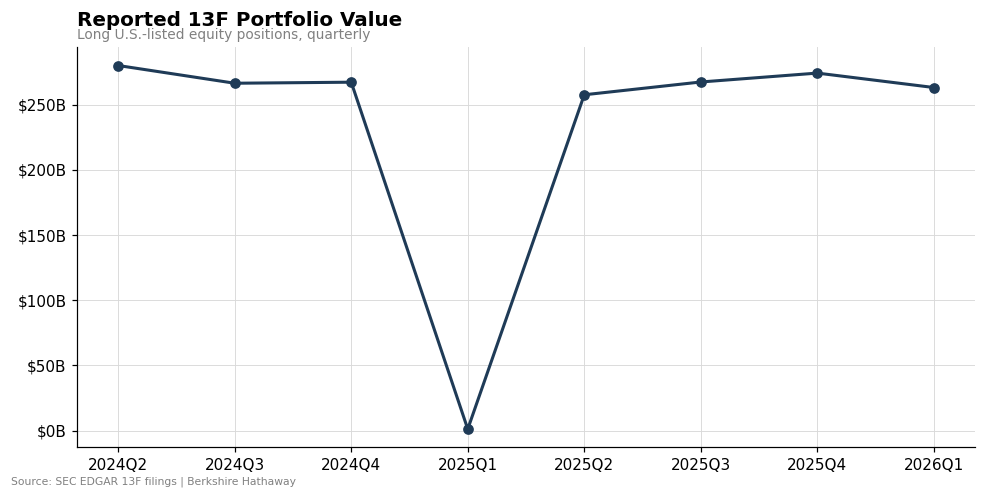

In [3]:
charts.plot_portfolio_value(summary);

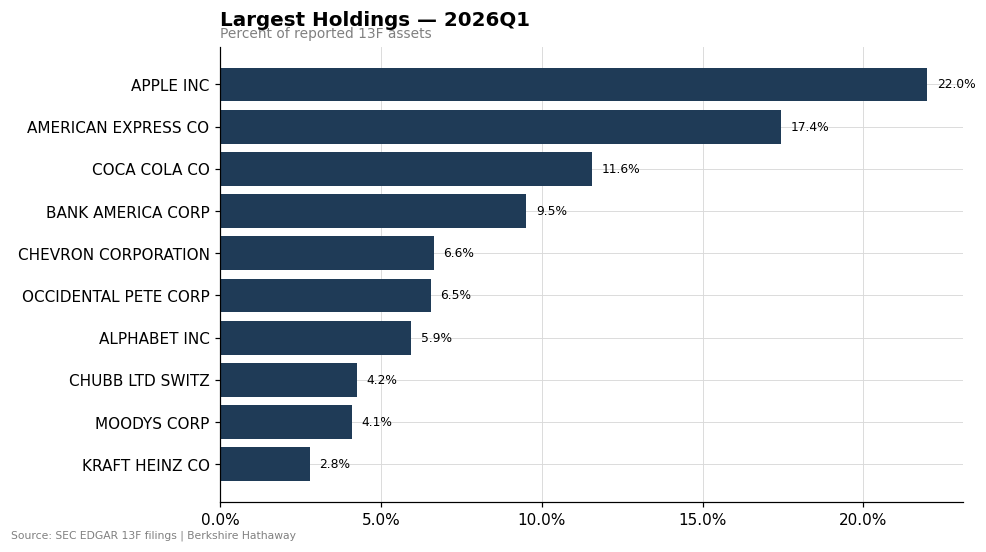

In [4]:
charts.plot_top_holdings(analytics.largest_holdings(holdings, latest), latest);

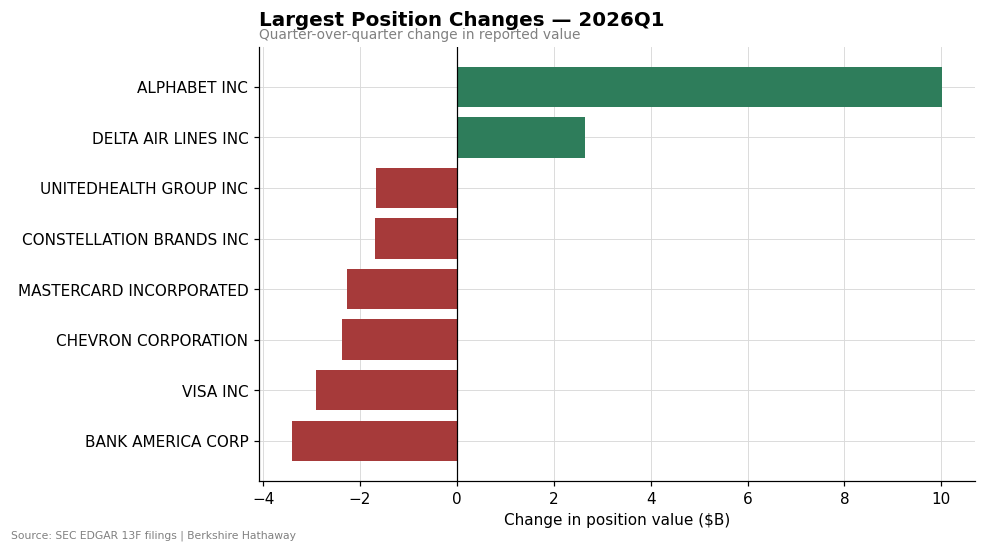

In [5]:
charts.plot_buys_sells(tx, latest);

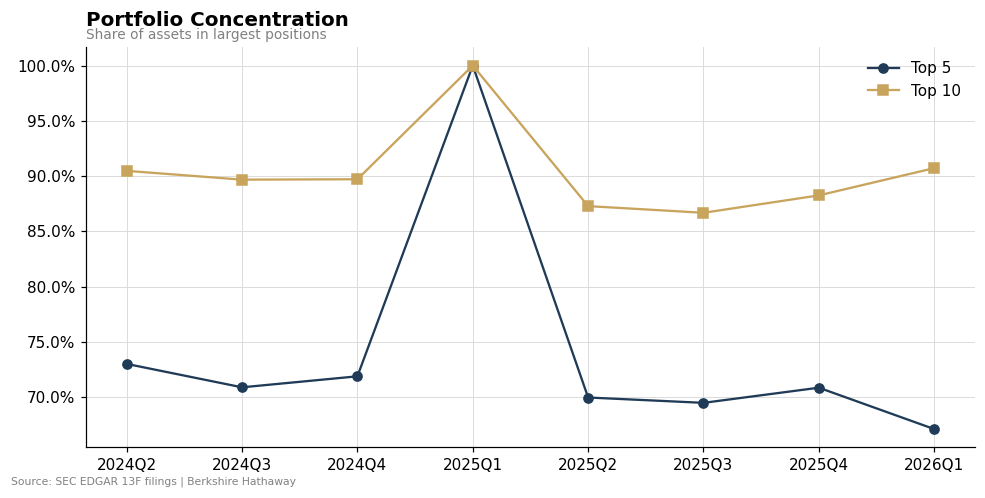

In [6]:
charts.plot_concentration(summary);

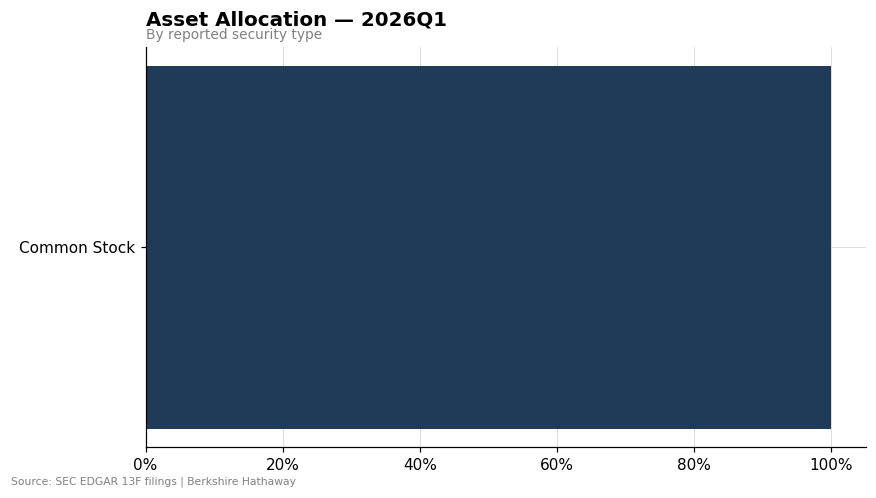

In [7]:
charts.plot_asset_allocation(analytics.asset_allocation(holdings, latest), latest);

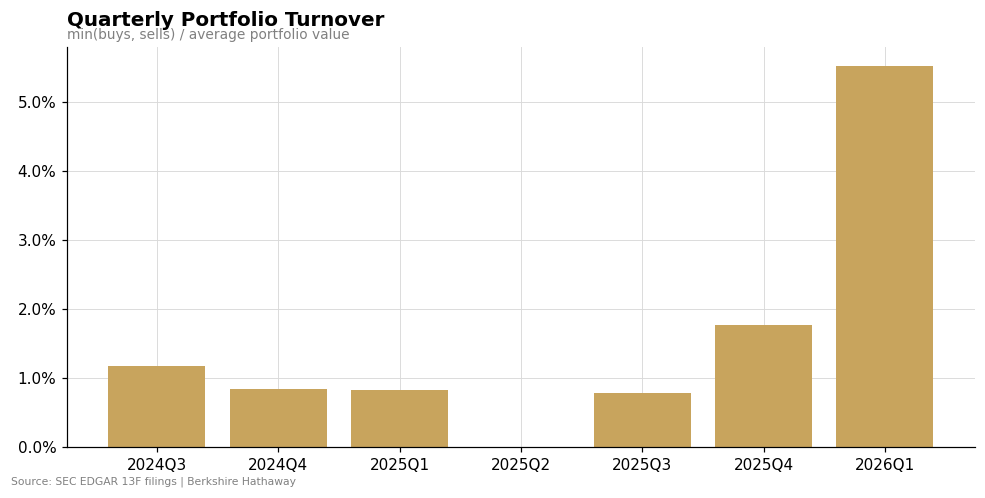

In [8]:
charts.plot_turnover(summary);

In [9]:
sorted(p.name for p in config.FIGURES_DIR.glob("*.png"))

['asset_allocation.png',
 'buys_sells.png',
 'concentration.png',
 'portfolio_value.png',
 'top_holdings.png',
 'turnover.png']